In [ ]:
1+1

## document loader

In [ ]:
from langchain_community.document_loaders import PyPDFDirectoryLoader,PyPDFLoader
from src.loging.logger import log
from src.exceptions.custom_exceptions import CustomException

logging=log



class DocumentLoader:
    def __init__(self,directory:str,):
        self.directory=directory
        logging.info("initialized docuemnt loader")

    def document_loader(self):
        rew_documents=PyPDFDirectoryLoader(self.directory)
        self.docs=rew_documents.load()
        if self.docs:
            try:
                pdf_files = set()
                for doc in self.docs:
                    source = doc.metadata.get('source', 'unknown')
                    pdf_files.add(source)
                # Log each PDF file
                logging.info(f"✅ Successfully loaded {len(self.docs)}  , documents lent is  {len(pdf_files)} PDF files:")
                for pdf in pdf_files:
                    logging.info(f" 📄 {pdf}")
                
            except Exception as e:
                    logging.error(f"error in loading documents : {e}")
                    raise CustomException(
                        message=f"Failed to load documents {e}",
                        error_detail=e
                    )
        elif not self.docs:
            logging.error(f" No documents found in {self.directory}")
            print(f"⚠️ No documents found in {self.directory}")
         
        return self.docs
    





In [ ]:
data = DocumentLoader("../data/")

In [ ]:
docs=data.document_loader()

In [ ]:
docs[0].metadata

In [ ]:
docs[0].metadata.get("source")

## embedings

In [ ]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from src.loging.logger import log
from src.exceptions.custom_exceptions import CustomException
import sys

logging=log


class Embeddings:

    def __init__(self,
        model_name:str="sentence-transformers/all-MiniLM-L6-v2",
        device: str = "cpu",
        normalize_embeddings: bool = True,
        batch_size: int = 32):

        self.model_name = model_name
        self.device = device
        self.normalize_embeddings = normalize_embeddings
        self.batch_size = batch_size
        self._embeddings = None
        logging.info("embedding get initialized")


    def initializing_embedding(self):
        if self._embeddings is None:
            try:
                self.embeddings = HuggingFaceEmbeddings(
                        model_name=self.model_name,
                        model_kwargs={'device': self.device},
                        encode_kwargs={
                            'normalize_embeddings': self.normalize_embeddings,
                            'batch_size': self.batch_size
                        }
                    )
                log.info(f"initialiased embeding model {HuggingFaceEmbeddings.__class__.__name__} with model name : {self.model_name}")
            except Exception as e:
                    logging.error(f"error during initilizing embedings : {e}")
                    raise CustomException(
                        f"Failed to initialize embeddings with model {self.model_name} or their is an error in embeding models {e}",
                        sys
                    )
        return self.embeddings

## chunker

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker   # ← FIXED
from langchain_community.document_loaders import PyPDFDirectoryLoader
from src.loging.logger import log
from src.exceptions.custom_exceptions import CustomException

logging=log



class TextSpliter:
    def __init__(self,embeding_model,persist_directory:str="vectorestore_VDB"):
        self.embeding=embeding_model
        self.persist_directory=persist_directory
        


    
    def split_documents(self,documents):
        # Split
        try:
            text_splitter = SemanticChunker(
                            embeddings=self.embeding,
                            breakpoint_threshold_type="percentile"
                        )

           
            chunks = text_splitter.split_documents(documents)
            logging.info(f"✅ Split {len(documents)} documents into {len(chunks)} chunks")
            return chunks
        except Exception as e:
            logging.error(f"❌ Error splitting documents: {e}")
            raise CustomException(f"Failed to chunk  {e}",sys)






## retriver

In [ ]:
from langchain_chroma import Chroma
from src.loging.logger import log
from src.exceptions.custom_exceptions import CustomException

logging=log
from pathlib import Path

class VectorStore:
    def __init__(self, embeddings, persist_directory):
        self.embeddings = embeddings
        self.persist_directory = persist_directory
        self.vectorstore = None
        Path(persist_directory).mkdir(parents=True, exist_ok=True)
        logging.info(f"✅ VectorStore initialized with persist_dir: {persist_directory}")

    def create_from_documents(self, documents):
        """Create vectorstore from documents"""
        try:
            self.vectorstore = Chroma.from_documents(
                documents=documents,
                embedding=self.embeddings,
                persist_directory=self.persist_directory
            )
            logging.info(f"✅ Created vectorstore with {len(documents)} documents")
            return self.vectorstore
        except Exception as e:
            logging.error(f"❌ Error creating vectorstore: {e}")
            raise CustomException("Failed to create vectorstore", e)

    def load_existing(self):
        """Load existing vectorstore"""
        try:
            self.vectorstore = Chroma(
                embedding_function=self.embeddings,
                persist_directory=self.persist_directory
            )
            logging.info(f"✅ Loaded existing vectorstore from {self.persist_directory}")
            print(f"✅ Loaded existing vectorstore from {self.persist_directory}")
            return self.vectorstore
        except Exception as e:
            logging.error(f"❌ Error loading vectorstore: {e}")
            raise CustomException("Failed to load vectorstore", e)

    def get_retriever(self, k: int = 4):
        """Get retriever from vectorstore"""
        if self.vectorstore is None:
            raise CustomException("Vectorstore not created yet. Call create_from_documents first.")
        return self.vectorstore.as_retriever(search_type="mmr",
                                             search_kwargs={"k": k,
                                                            "fetch_k": 20,
                                                            "lambda_mult": 0.5 })

In [ ]:
data = DocumentLoader("../data/PLAN_COMPTABLE")
docs=data.document_loader()
embeding_model=Embeddings()
embeding=embeding_model.initializing_embedding()
text_splietr=TextSpliter(embeding)
chunks=text_splietr.split_documents(docs)
vectore_store=VectorStore(embeding,"artifacts/vectorestore/CGI")
vectore_store.create_from_documents(chunks)
store=vectore_store.get_retriever()

In [ ]:
print(chunks[2].page_content)

In [ ]:
store.invoke("tva recuperable sur charge")

In [ ]:
from src.PipeLine.pipeline import  RagPipeLine

In [ ]:
pipeline=RagPipeLine(data_dir="../data/PLAN_COMPTABLE",persist_dir="artifacts/vectorestore/plan_comptable",force_rebuild=False)

In [ ]:
pip=pipeline.run()

In [ ]:
result=pip.invoke("les cadaux publicitaire dans  IR")
for i in range(len(result)):
    print(result[i].page_content)
    print("___________________________________________")

In [ ]:
result

In [1]:
from src.tools.plan_comptable import plan_comptable_tool
from src.tools.cgnc import cgnc_tool
from src.tools.finance_law import finance_law_tool
from src.tools.tax import CGI_tool
from src.tools.web_search_tool import search

c:\dev\aaa\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-26 00:39:26,461 - INFO - embedding get initialized



🚀 RAG Pipeline initialized
📂 Data: ../data/PLAN_COMPTABLE
💾 Persist: artifacts/vectorestore/db_plan_comptable
🔍 Vectorstore exists: True



2026-05-26 00:39:27,128 - INFO - initialiased embeding model OpenAIEmbeddings with model name : text-embedding-3-large
2026-05-26 00:39:27,129 - INFO - ✅ VectorStore initialized with persist_dir: artifacts/vectorestore/db_plan_comptable
2026-05-26 00:39:27,216 - INFO - ✅ Loaded Chroma from artifacts/vectorestore/db_plan_comptable
2026-05-26 00:39:27,218 - INFO - ✅ Loaded BM25 index from artifacts\vectorestore\db_plan_comptable\bm25_index.pkl
2026-05-26 00:39:27,218 - INFO - ✅ Hybrid retriever restored
2026-05-26 00:39:27,222 - INFO - embedding get initialized
2026-05-26 00:39:27,243 - INFO - initialiased embeding model OpenAIEmbeddings with model name : text-embedding-3-large
2026-05-26 00:39:27,244 - INFO - ✅ VectorStore initialized with persist_dir: artifacts/vectorestore/db_CGNC
2026-05-26 00:39:27,263 - INFO - ✅ Loaded Chroma from artifacts/vectorestore/db_CGNC
2026-05-26 00:39:27,275 - INFO - ✅ Loaded BM25 index from artifacts\vectorestore\db_CGNC\bm25_index.pkl
2026-05-26 00:39:2

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from artifacts/vectorestore/db_plan_comptable

🚀 RAG Pipeline initialized
📂 Data: ../data/CGNC
💾 Persist: artifacts/vectorestore/db_CGNC
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from artifacts/vectorestore/db_CGNC

🚀 RAG Pipeline initialized
📂 Data: ../data/LOIS_DE_FINANCE
💾 Persist: artifacts/vectorestore/LOIS_DE_FINANCE
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...


2026-05-26 00:39:27,320 - INFO - ✅ Loaded Chroma from artifacts/vectorestore/LOIS_DE_FINANCE
2026-05-26 00:39:27,345 - INFO - ✅ Loaded BM25 index from artifacts\vectorestore\LOIS_DE_FINANCE\bm25_index.pkl
2026-05-26 00:39:27,346 - INFO - ✅ Hybrid retriever restored
2026-05-26 00:39:27,348 - INFO - embedding get initialized
2026-05-26 00:39:27,367 - INFO - initialiased embeding model OpenAIEmbeddings with model name : text-embedding-3-large
2026-05-26 00:39:27,369 - INFO - ✅ VectorStore initialized with persist_dir: artifacts/vectorestore/db_CGI
2026-05-26 00:39:27,390 - INFO - ✅ Loaded Chroma from artifacts/vectorestore/db_CGI
2026-05-26 00:39:27,427 - INFO - ✅ Loaded BM25 index from artifacts\vectorestore\db_CGI\bm25_index.pkl
2026-05-26 00:39:27,428 - INFO - ✅ Hybrid retriever restored


✅ Loaded existing vectorstore from artifacts/vectorestore/LOIS_DE_FINANCE

🚀 RAG Pipeline initialized
📂 Data: ../data/CGI
💾 Persist: artifacts/vectorestore/db_CGI
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from artifacts/vectorestore/db_CGI


In [2]:
tools=[cgnc_tool,finance_law_tool,CGI_tool,plan_comptable_tool,search]

In [3]:
from  dotenv import  load_dotenv

from langchain_openrouter import ChatOpenRouter
import os

import os

load_dotenv()


os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY")  

MODEL = "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free"
llm = ChatOpenRouter(model=MODEL)

In [5]:
llm.invoke("what is todays date")

2026-05-26 00:26:08,490 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


AIMessage(content="Today's date isNovember\u202f2,\u202f2025.", additional_kwargs={'reasoning_content': 'User asks "what is todays date". The system date is provided: 2025-11-02. So answer: November 2, 2025. Probably just give date.\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'User asks "what is todays date". The system date is provided: 2025-11-02. So answer: November 2, 2025. Probably just give date.\n'}]}, response_metadata={'model_name': 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning-20260428:free', 'id': 'gen-1779751571-sIZYCQtVxj64WqGpLt78', 'created': 1779751571, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019e61ac-ad42-7331-847b-ee10b4a0e85d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 62, 'total_tokens': 83, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning':

In [4]:
llm_with_tools=llm.bind_tools(tools)

In [6]:
result=llm_with_tools.invoke("what is tva recuperable sur charge ")
print(result)

2026-05-24 18:48:06,555 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


content='' additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user is asking about "tva recuperable sur charge". First, I need to figure out which tool to use. The query mentions TVA (Taxe sur la Valeur Ajoutée) and "recuperable", which is French for "recoverable". So, this is related to VAT recovery on charges.\n\nLooking at the tools available: there\'s the code_general_des_impots_morocco (CGI) for tax law, plan_comptable_general_marocain (PCGM) for account numbers, code_general_normalisation_comptable_maroc (CGNC) for accounting standards, and loi_de_finances_maroc (LF) for the budget law.\n\nThe user is asking about the recoverable VAT on charges. In accounting terms, "TVA récupérable" refers to the VAT that a business can reclaim from the tax authorities. The relevant account here would be the one where the recoverable VAT is recorded. From the PCGM tool\'s description, accounts like 3455 (TVA récupérable) are part of the chart of accounts.\n\nSo, the user needs to kno

In [5]:
SYSTEM_PROMPT = """You are a Moroccan accounting and tax assistant. 
Follow this STRICT routing hierarchy:

1. Need an ACCOUNT NUMBER → plan_comptable_marocain
2. Need an ACCOUNTING RULE or PRINCIPLE → cgnc_maroc  
3. Need a TAX RATE or PERMANENT TAX RULE → cgi_maroc
4. Need a RECENT/ANNUAL tax change with YEAR mentioned → loi_finances_maroc
5. Need CURRENT news, exchange rates, or outside info → google_search

NEVER invent article numbers. If the retrieved text doesn't contain the answer, say so."""

In [6]:
from langchain_core.messages import AIMessage, HumanMessage,SystemMessage

from langgraph.graph import StateGraph, START, END 
from  langgraph.prebuilt import ToolNode
from typing import TypedDict,List
from typing_extensions import Annotated
from langgraph.graph import add_messages

from  dotenv import  load_dotenv

from langchain_openrouter import ChatOpenRouter
import os

import os

os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY")  

MODEL = "nvidia/nemotron-3-super-120b-a12b:free"
llm = ChatOpenRouter(model=MODEL)


llm_with_tools=llm.bind_tools(tools)



class AgentState(TypedDict):
    messages:Annotated[List,add_messages]

def chat_node(state: AgentState) -> dict:
    """A simple node that appends an AI response."""
    # `state["messages"]` already contains the full conversation history
    last_human_msg = state["messages"][-1].content if state["messages"] else ""

    response = llm_with_tools.invoke(last_human_msg)

    return {"messages": [response]}

tool_node=ToolNode(tools)

def agent_structuring_response(state: AgentState):
    # Find the last ToolMessage to know which tool was used
    
    system_message = SystemMessage(content=SYSTEM_PROMPT)

    all_messages = [system_message] + state["messages"][-5:]
    return {"messages": [llm_with_tools.invoke(all_messages)]}


from langgraph.prebuilt import tools_condition



# ── Build the graph ──
builder = StateGraph(AgentState)
builder.add_node("chat", chat_node)
builder.add_node("tool_node", tool_node)
builder.add_node("structures", agent_structuring_response)


builder.add_edge(START, "chat")
builder.add_edge("chat", "tool_node")
builder.add_edge("tool_node", "structures")
builder.add_conditional_edges(
    "structures",
    tools_condition,
    {
        "tools": "tool_node",
        "__end__": END
    }
)
builder.add_edge("structures", END)



graph = builder.compile()



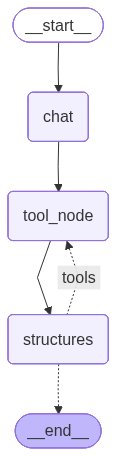

In [9]:
graph

In [8]:
# ── Invoke ──
result = graph.invoke({"messages": [HumanMessage(content="COMMENT COMPTABILISE LES OPERATION ON DEVISE ? UN EXEPMLE DE UN ACHAT DE MATERIEL DE TRANSPORT POUR 20000 USD en  23 MAY 2026 moitier ent in same date et le moitier en 01/03/0227 ")]})
result["messages"]

2026-05-26 00:44:46,714 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-26 00:45:05,692 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-26 00:45:08,801 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-05-26 00:45:22,213 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-26 00:46:44,507 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-05-26 00:47:01,223 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


[HumanMessage(content='COMMENT COMPTABILISE LES OPERATION ON DEVISE ? UN EXEPMLE DE UN ACHAT DE MATERIEL DE TRANSPORT POUR 20000 USD en  23 MAY 2026 moitier ent in same date et le moitier en 01/03/0227 ', additional_kwargs={}, response_metadata={}, id='5f786e2c-c451-4f07-9943-22ee0b8c6fe8'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer in French (user wrote French). The question: "COMMENT COMPTABILISE LES OPERATION ON DEVISE ? UN EXEPMLE DE UN ACHAT DE MATERIEL DE TRANSPORT POUR 20000 USD en 23 MAY 2026 moitier ent in same date et le moitier en 01/03/0227". So they ask: How to account for foreign currency operations? Example purchase of transport equipment for 20000 USD on 23 May 2026 half paid immediately same date and the other half on 01/03/2027.\n\nWe need to provide accounting entries according to Moroccan accounting standards (CGNC). Use cgnc_maroc for rules on foreign currency operations. Also we might need plan_comptable for account numbers 

In [9]:
import pprint

x=result["messages"][-1].content
pprint.pprint(x)

('**Conversion en dirham d’un actif immobilisé acquis en monnaie étrangère – '
 'traitement selon le PCG marocain (CGNC)**  \n'
 '\n'
 '| Étape | Comptabilisation | Comptes utilisés (exemple) | Explication |\n'
 '|-------|------------------|----------------------------|-------------|\n'
 '| **1.\u202fAcquisition (date d’entrée)** | Conversion du coût en devise '
 'étrangère au **taux de change du jour de l’opération** (date de facturation, '
 'de l’accord ou de paiement). | • Débit du compte d’immobilisation concerné '
 '(classe\u202f23) –\u202fex.\u202f2321\u202f«\u202fBâtiments\u202f», '
 '2332\u202f«\u202fMatériel et outillage\u202f», 2340\u202f«\u202fMatériel de '
 'transport\u202f», etc.<br>• Crédit du compte de paiement ou de dette '
 '(ex.\u202f5141\u202f«\u202fBanque\u202f», 4411\u202f«\u202fFournisseurs\u202f'
 '») pour le montant en dirhams obtenu. | L’actif est inscrit à sa **valeur '
 'd’entrée historique** (coût en dirhams au taux du jour d’entrée). Aucune '
 'réévaluation